# Fractional orbital, direct orbital and ballistic: rendered from the simulation state

Four profiles between the same two points, rendered on a ray-traced globe by
`passes.viz`. The notebook holds no trajectory model, no camera arithmetic and
no drawing code of its own — it builds histories, hands them to a
`TrajectoryAnimator`, and prints numbers.

## Why that matters, and what it cost to learn

The previous version of this notebook carried its own notion of where the
vehicle was, rebuilt in a cell from sub-satellite points and altitudes. That is
a **second trajectory model**. It was fed by the real one and so mostly agreed
with it, but nothing enforced the agreement, and three defects found by
watching the output were all of that kind — invisible to every physics test,
because the physics did not know the animation existed:

| defect | symptom | cause |
| --- | --- | --- |
| animations stopped at 86 % of the flight | ended at 130 km, no descent | `frame * (len(samples) // n_frames)` truncates; last frame hit sample 774 of 899 |
| the fractional profile began at 150 km | opened with the vehicle already in orbit | `fobs_trajectory` had no ascent |
| the chase camera was 96 km underground at lift-off | black frame, floating track, no Earth | boost heading is radial, so stepping *back* also steps *down* |

A fourth was found the same way and was not a rendering defect at all: the HUD
read 150 km for the whole flight because the **descent was faked** — a linear
ramp giving 2.9 min at 850 m/s vertical, where the verified `deorbit_burn` in
the same package gives 8.3 min over 33.7° of arc. It now runs on the real
transfer conic.

`passes.viz.history.SimulationHistory` removes the second model. It is the one
record of a run; the renderer samples it and reconstructs nothing. Both
producers feed it — `from_flight_result` for the coupled multi-physics
simulator, carrying position, velocity, attitude quaternion, heat flux,
recession and dynamic pressure; `from_trajectory` for the lighter orbital
scenarios, which carry position and time and *declare that they carry no
attitude* rather than substituting an identity quaternion.


## 1. Four profiles, one aimpoint


In [9]:
import numpy as np

from passes.geodesy import GeodeticPosition, great_circle_range, WGS84_MEAN_RADIUS
from passes.guidance.lofting import optimum_burnout_angle
from passes.orbital.radar import EARLY_WARNING_SITES, coverage, network
from passes.orbital.scenario import ballistic_trajectory, fobs_trajectory
from passes.viz import SimulationHistory

R = WGS84_MEAN_RADIUS
LAUNCH = GeodeticPosition.from_degrees(51.0, 59.0, 120.0, "Dombarovskiy")
TARGET = GeodeticPosition.from_degrees(38.87, -77.06, 24.0, "aimpoint")
# Insertion (perigee) and apogee of the parking orbit. 170 x 250 km sits in
# the band open sources quote for the R-36O; the warning-analysis notebook
# sweeps it from 120 to 500 km rather than resting on one number.
PARKING_ALTITUDE = 170e3
PARKING_APOGEE = 250e3
SAMPLES = 900

# The US/NATO network, not the whole catalogue. `coverage` reduces a network to
# its EARLIEST detection, and EARLY_WARNING_SITES contains sensors that are not
# on this picture at all — two Russian early-warning radars and one non-aligned
# South African site. Running a Eurasian launch past all of it reports a
# Russian radar 900 km from the pad seeing its own missile.
SITES = network("western")

theta = float(great_circle_range(LAUNCH, TARGET) / R)
depressed_angle = 0.55 * optimum_burnout_angle(theta)

PROFILES = {
    "fractional (long way)": fobs_trajectory(
        LAUNCH, TARGET, parking_altitude=PARKING_ALTITUDE,
        parking_apogee=PARKING_APOGEE, samples=SAMPLES),
    "fractional (direct)": fobs_trajectory(
        LAUNCH, TARGET, parking_altitude=PARKING_ALTITUDE,
        parking_apogee=PARKING_APOGEE, samples=SAMPLES, direction="short"),
    "ballistic (minimum energy)": ballistic_trajectory(LAUNCH, TARGET, samples=SAMPLES),
    "ballistic (depressed)": ballistic_trajectory(
        LAUNCH, TARGET, flight_path_angle=depressed_angle, samples=SAMPLES),
}
COVERAGE = {
    name: coverage(t.times, t.altitudes, t.subpoints, SITES)
    for name, t in PROFILES.items()
}
HISTORIES = {name: SimulationHistory.from_trajectory(t, R) for name, t in PROFILES.items()}

print(f"separation {great_circle_range(LAUNCH, TARGET)/1e3:,.0f} km "
      f"({np.rad2deg(theta):.1f} deg of arc)")
excluded = [s.name for s in EARLY_WARNING_SITES if s.coalition != "western"]
print(f"defender network: {len(SITES)} of {len(EARLY_WARNING_SITES)} catalogued sensors")
print(f"not on a US/NATO picture: {', '.join(excluded)}\n")
def entry_angle(trajectory):
    detail = next(e.detail for e in trajectory.events if e.name == "entry interface")
    return float(detail.split("gamma")[1].split("deg")[0])


print(f"{'profile':28}{'arc':>6}{'apogee':>8}{'flight':>8}{'V_bo':>8}"
      f"{'warning':>9}{'sites':>7}{'entry':>8}  first detector")
for name, t in PROFILES.items():
    c = COVERAGE[name]
    warn = c.warning_time / 60 if c.detected else float("nan")
    print(f"{name:28}{np.rad2deg(t.range_angle):6.0f}{t.apogee/1e3:8,.0f}"
          f"{t.flight_time/60:8.1f}{t.burnout_speed:8,.0f}{warn:9.1f}"
          f"{len(c.detecting_sites):7d}{entry_angle(t):7.1f}d  {c.first_detecting_site}")
print("\ndeg | km | min | m/s | min | count | entry flight-path angle, deg")

print(f"\n{PROFILES['fractional (long way)'].label} structure:")
for phase in PROFILES["fractional (long way)"].phases:
    print(f"  {phase.name:15} T+{phase.start_time/60:6.2f} -> {phase.end_time/60:6.2f} min"
          f"   {phase.note}")
for event in PROFILES["fractional (long way)"].events:
    print(f"  * {event.name:16} T+{event.time/60:6.2f} min   {event.detail}")


separation 9,146 km (82.2 deg of arc)
defender network: 19 of 22 catalogued sensors
not on a US/NATO picture: Cape Town, Okno (Zelenograd), Krasnoyarsk

profile                        arc  apogee  flight    V_bo  warning  sites   entry  first detector
fractional (long way)          285     250    71.8   7,830     49.7      2   -2.5d  Exmouth
fractional (direct)             80     171    21.2   7,830     16.0      1   -1.7d  Globus II/III
ballistic (minimum energy)      80   1,301    29.8   6,986     27.3      9  -24.5d  Globus II/III
ballistic (depressed)           80     608    24.0   7,176     20.8      8  -12.6d  Globus II/III

deg | km | min | m/s | min | count | entry flight-path angle, deg

fractional-orbital structure:
  boost           T+  0.00 ->   3.00 min   gravity turn to 170 km, burnout gamma 3.9 deg
  parking coast   T+  3.00 ->  53.65 min   170 x 250 km, e = 0.0061
  deorbit coast   T+ 53.65 ->  67.28 min   8,159 km of ground track to the interface
  entry           T+ 6

## 2. Whose network? A defect in every earlier warning figure

`coverage` reduces a sensor network to the time of its **earliest**
detection. That is the right composition for warning — one site is enough to
raise an alarm — but it means the network has to be *one side's*.

`EARLY_WARNING_SITES` is a catalogue, and it contains two Russian
early-warning radars alongside nineteen western ones and one non-aligned
South African site, none of which would be on a US/NATO warning picture. Their own notes say so
("Included for geographic completeness, not as a US/NATO system"), but nothing
enforced it, and every warning figure this notebook previously printed was
computed against the union. For a launch from Dombarovskiy the consequence is
concrete: three of the four profiles were first "detected" by **Okno**, a
Russian radar 900 km from the pad, at T+0.8 min. That is not warning to anyone.

The correction is not merely arithmetic — it changes *which sensor sets the
answer*, and therefore which coverage gap the analysis is about:

| profile | full catalogue | western only |
| --- | --- | --- |
| fractional (long way) | 49.7 min, Exmouth | 49.7 min, Exmouth |
| fractional (direct) | 19.1 min, Okno | **16.0 min, Globus II/III** |
| ballistic (minimum energy) | 29.0 min, Okno | **27.3 min, Globus II/III** |
| ballistic (depressed) | 22.9 min, Okno | **20.8 min, Globus II/III** |

`RadarSite.coalition` now records the side, `radar.network(...)` selects one,
and `warning_comparison` defaults to `network("western")`. Cape Town is
excluded with the Russian pair: its own entry records that it is not
integrated into any western early-warning network, so its returns are not on
this picture either.
The long-way profile is unaffected, because it was already being caught first
by an Australian sensor half a world from the launch site — which is the point
of the profile and, as section 6 shows, also its weakness.

## 3. The direct fractional profile is the control that was missing

The fractional concept bundles two separate claims — that flying **low** denies
horizon, and that arriving on the **reversed bearing** denies azimuth coverage
— and a single warning number for the pair cannot say which is doing the work.
`direction="short"` flies the identical parking altitude and identical orbital
insertion energy down the *minor* arc, on the direct bearing. Whatever it
concedes is what altitude alone buys.

Against this 22-site network the decomposition is unflattering to the long way
round:

- **The small detecting set comes from altitude, not from the bearing.** The
  direct low profile is seen by **1** site and the long way by 2, against 8 and
  9 for the two ballistic arcs. Both fractional profiles stay under 250 km, so
  most of the chain never has them above its horizon mask.
- **The long way round then *costs* warning.** 49.7 min against 16.0, because
  warning runs from *first* detection and the long way flies for 72 minutes
  against 21. One southern station picking it up at T+26 leaves three quarters
  of a much longer flight to be tracked.
- **The direct fractional profile beats the depressed ballistic arc** — 16.0 min
  against 20.8 — at a shorter flight time, but it pays 7,830 m/s of insertion
  speed against 7,176, and full orbital insertion is not a small premium.
- **And both fractional profiles enter an order of magnitude shallower.** The
  entry flight-path angle column is the price nobody charges the concept for:
  −2.5° and −1.7° against −24.5° and −12.6°. Deorbiting from orbital speed
  cannot buy a steep entry without removing kilometres per second, so the
  descent conic spans some 8,000 km of ground track and the vehicle is
  committed a quarter of the planet before impact.

None of that says a fractional profile is pointless. It says that against a
horizon-geometry model, the reversed bearing buys nothing and the value must
lie in something this model does not price — arriving from an azimuth the
defence's interceptors and battle management are not oriented along, which is
not the same thing as radar horizon.


## 4. Establishing shot


render backend: cupy


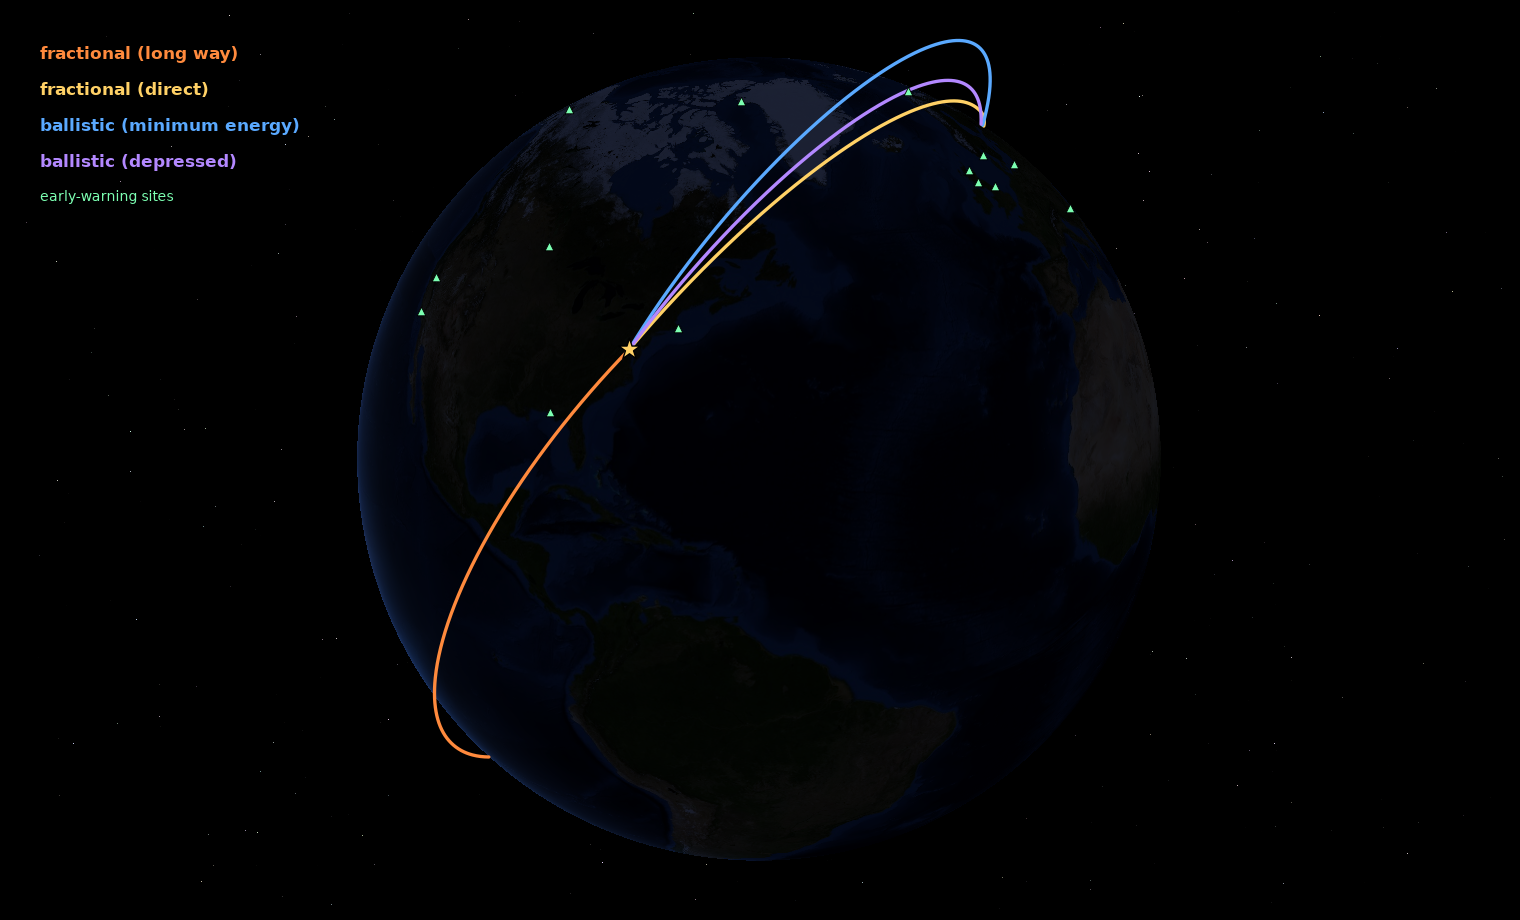

In [10]:
import matplotlib.pyplot as plt

from passes.viz import (
    draw_marker, draw_sites, draw_track, geodetic_to_cartesian, globe_plate,
    load_texture, look_at, sun_direction, to_device,
)

from passes.batch.backend import cuda_available

# Same backend switch as the batched integrator. The GPU path is the same
# renderer, agreeing with the CPU to 1e-11 in a colour channel, and about
# 15x faster on a 1280x720 frame (344 ms -> 22 ms).
BACKEND = "cupy" if cuda_available() else "numpy"
# Uploaded once: a 4096x2048x3 float64 texture is 200 MB, and moving it per
# frame would cost more than the render it was meant to accelerate.
TEXTURE = to_device(load_texture(), BACKEND)
print(f"render backend: {BACKEND}")
COLORS = {
    "fractional (long way)": "#FF8A3D",
    "fractional (direct)": "#FFD166",
    "ballistic (minimum energy)": "#5AA9FF",
    "ballistic (depressed)": "#B388FF",
}

launch_xyz = geodetic_to_cartesian(LAUNCH, R, lift=20e3)
target_xyz = geodetic_to_cartesian(TARGET, R, lift=20e3)

# Sun over the middle of the long-way route rather than a hand-set longitude:
# that route runs over the southern hemisphere, and a fixed subsolar point left
# most of it over unlit Antarctica — correct, and unreadable.
mid = PROFILES["fractional (long way)"].subpoints[SAMPLES // 2]
SUN = sun_direction(mid.longitude, float(np.clip(mid.latitude, -np.pi / 6, np.pi / 6)))

mid_xyz = 0.5 * (launch_xyz + target_xyz)
camera = look_at(np.zeros(3), 3.4 * R,
                 azimuth=float(np.arctan2(mid_xyz[1], mid_xyz[0])) - np.deg2rad(35),
                 elevation=np.deg2rad(28), fov=np.deg2rad(38), width=1500, height=900)

fig, ax = globe_plate(camera, TEXTURE, R, sun=SUN, backend=BACKEND)
for name, history in HISTORIES.items():
    draw_track(ax, history.positions, camera, color=COLORS[name], width=2.4,
               body_radius=R)
draw_sites(ax, SITES, camera, body_radius=R)
draw_marker(ax, launch_xyz, camera, body_radius=R, s=130, marker="v", c="white",
            edgecolors="black", linewidths=1.2, zorder=6)
draw_marker(ax, target_xyz, camera, body_radius=R, s=260, marker="*", c="#FFD166",
            edgecolors="black", linewidths=1.0, zorder=6)
for offset, (name, color) in enumerate(COLORS.items()):
    ax.text(0.02, 0.96 - 0.04 * offset, name, transform=ax.transAxes, color=color,
            fontsize=12, va="top", weight="bold")
ax.text(0.02, 0.96 - 0.04 * len(COLORS), "early-warning sites", transform=ax.transAxes,
        color="#7CFFB2", fontsize=10, va="top")
plt.show()


The two fractional tracks separate immediately and never meet again: one leaves
on the bearing of the target, the other on its reverse. The long-way track
disappears behind the limb for most of its flight, and that occlusion is the
depth test working — it is also the argument, since the vehicle is below the
horizon of everything on this face of the planet.

## 5. The southern approach

Viewed from below the equator, the long-way track is fully exposed. This is the
view that used to make the case for the profile — a long flight over a
hemisphere with almost no early-warning coverage, arriving on the reversed
bearing. It is also the view that shows why the case does not hold: the
southern sensors are sparse but **not absent**.


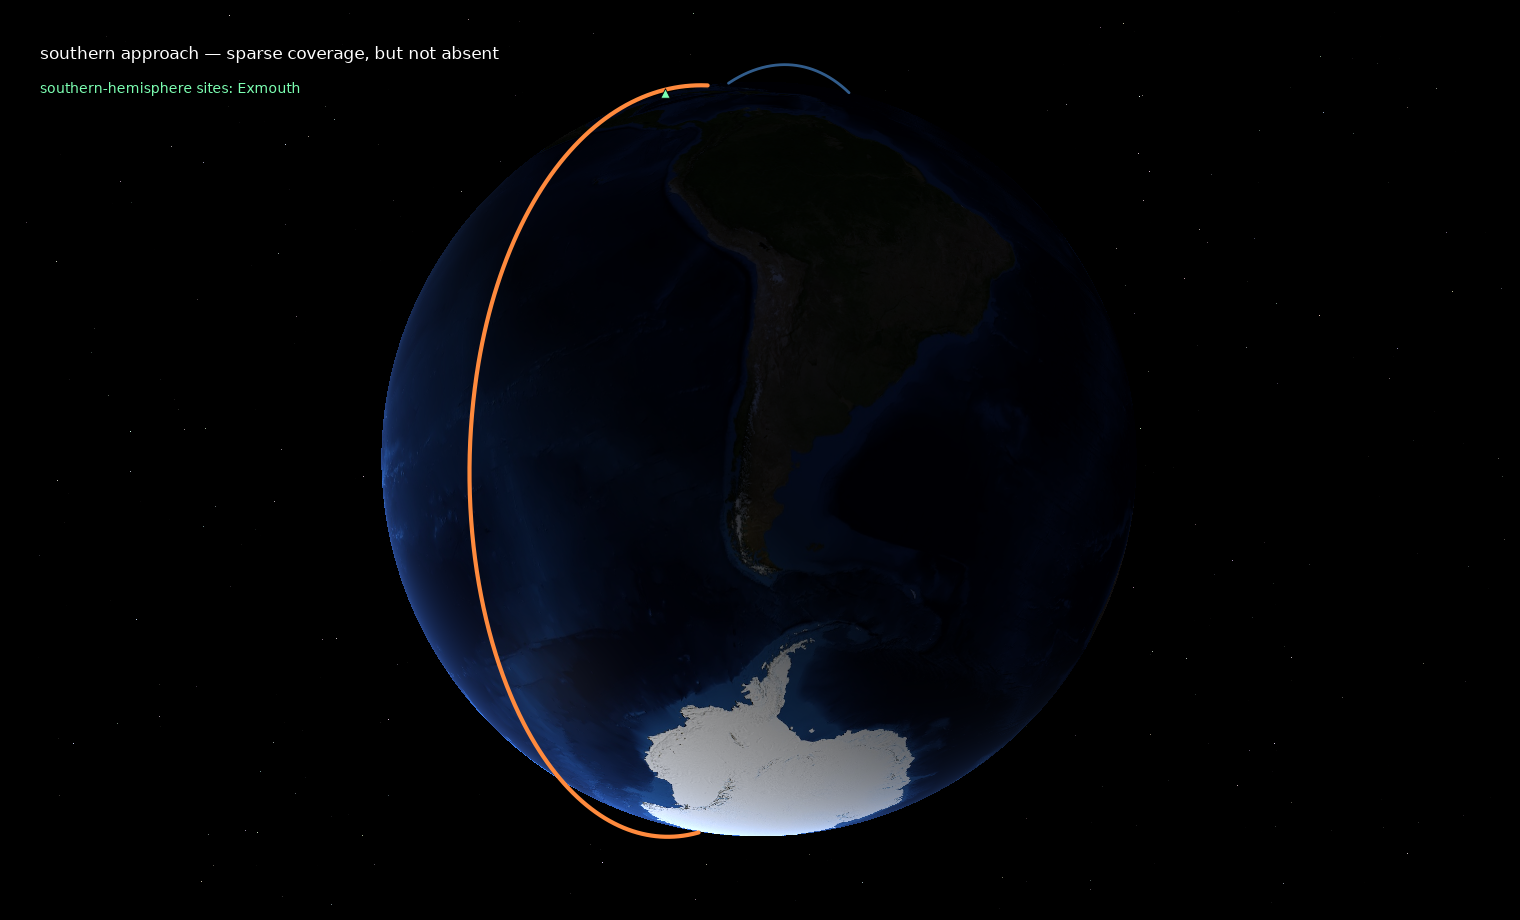

In [11]:
camera_s = look_at(np.zeros(3), 3.6 * R, azimuth=np.deg2rad(-70),
                   elevation=np.deg2rad(-42), fov=np.deg2rad(38),
                   width=1500, height=900)
fig, ax = globe_plate(camera_s, TEXTURE, R, sun=SUN, ambient=0.14, backend=BACKEND)
draw_track(ax, HISTORIES["ballistic (minimum energy)"].positions, camera_s,
           color=COLORS["ballistic (minimum energy)"], width=2.0, alpha=0.55, body_radius=R)
draw_track(ax, HISTORIES["fractional (long way)"].positions, camera_s,
           color=COLORS["fractional (long way)"], width=3.0, body_radius=R)
draw_sites(ax, SITES, camera_s, body_radius=R, size=46)
draw_marker(ax, target_xyz, camera_s, body_radius=R, s=260, marker="*", c="#FFD166",
            edgecolors="black", linewidths=1.0, zorder=6)

southern = [s for s in SITES if s.position.latitude < 0]
ax.text(0.02, 0.96, "southern approach — sparse coverage, but not absent",
        transform=ax.transAxes, color="white", fontsize=12, va="top")
ax.text(0.02, 0.92, "southern-hemisphere sites: " + ", ".join(s.name for s in southern),
        transform=ax.transAxes, color="#7CFFB2", fontsize=10, va="top")
plt.show()


## 6. One sensor decides the answer

The advantage the long-way profile is supposed to buy turns on whether *any*
station sees it early. Removing sensors one at a time isolates which.


In [12]:
def warning_for(sites, trajectory):
    result = coverage(trajectory.times, trajectory.altitudes, trajectory.subpoints,
                      tuple(sites))
    return (result.warning_time / 60 if result.detected else float("nan")), result


full = list(SITES)
cases = {
    f"full network ({len(full)} sites)": full,
    "drop southern hemisphere": [s for s in full if s.position.latitude >= 0],
    "drop Exmouth only": [s for s in full if "Exmouth" not in s.name],
    "drop Fylingdales only": [s for s in full if "Fylingdales" not in s.name],
}
long_way = PROFILES["fractional (long way)"]
ballistic = PROFILES["ballistic (minimum energy)"]

print(f"{'network':30}{'ballistic':>11}{'long-way':>11}{'advantage':>11}  first detector")
for label, subset in cases.items():
    ball, _ = warning_for(subset, ballistic)
    frac, cover = warning_for(subset, long_way)
    print(f"{label:30}{ball:11.1f}{frac:11.1f}{ball - frac:+11.1f}  "
          f"{cover.first_detecting_site or 'none'}")
print("\nWarning is measured from FIRST detection to impact, and the long-way profile")
print("flies for 72 min against the ballistic arc's 30. One early detection therefore")
print("costs it more than being seen by nine late ones.")


network                         ballistic   long-way  advantage  first detector
full network (19 sites)              27.3       49.7      -22.3  Exmouth
drop southern hemisphere             27.3        3.9      +23.4  Eglin
drop Exmouth only                    27.3        3.9      +23.4  Eglin
drop Fylingdales only                27.3       49.7      -22.3  Exmouth

Warning is measured from FIRST detection to impact, and the long-way profile
flies for 72 min against the ballistic arc's 30. One early detection therefore
costs it more than being seen by nine late ones.


Dropping **Exmouth alone** restores the entire advantage; dropping a
well-placed northern site such as Fylingdales changes nothing. The result is
not a property of southern coverage in general, nor of network size, but of one
station that happens to lie under this particular track.

That fragility is the finding. A conclusion a single sensor can invert is not a
robust operational advantage, and any warning figure quoted from this framework
should be accompanied by the network it was computed against.

## 7. Chase animations — one per profile, from the history

Each profile gets its own animation. Showing two at once meant one of them was
always the wrong scale: a fractional profile sits at a constant 150 km while a
minimum-energy arc peaks near 1300 km, and a camera framed for either makes the
other a line in the corner. `ChaseRig` scales its stand-off with the vehicle's
own altitude, so one rig frames both without retuning.

### Making a 72-minute flight legible

Three complaints drove the rest of this section, and all three were fair.

**The parking and deorbit legs were invisible.** A chase camera at orbital
altitude shows scrolling ground and little else, so there was no way to tell a
parking coast from a deorbit coast, or to judge how much flight was left. The
trajectory now *declares* its phases and events — boost, parking coast, deorbit
coast, entry, with lift-off, insertion, the deorbit burn, the entry interface
and impact between them — and the frame shows the current phase, the next event
with a countdown, a diamond at each event's location, and a timeline strip.

**The timing was impossible to follow.** Uniform pacing is defensible and
unwatchable: this profile is 4 % boost, 71 % parking coast and 25 % descent, so
at 130 frames the entire powered ascent got 6 of them. `pacing="phase"` gives
each leg a share set by `duration ** 0.45` — boost 6→17 frames, entry 8→20,
parking 91→60 — and the HUD states the resulting playback rate, which is ×215
through boost and ×1,016 through the coast. The timeline stays **linear in
flight time** on purpose, so the playhead visibly crawls through the coast and
sprints through entry rather than hiding the distortion.

**The chase was too dark.** Lighting from the camera removes the terminator,
which is why it was chosen, but a chase camera looks roughly *along* the
surface, so everything it can see is at grazing incidence to a light behind the
lens. `lighting="track"` puts a key light on the vehicle's own local vertical
instead. It is not a sun and does not pretend to be one.

The whole notebook body for an animation is now three lines, and the properties
that used to be enforced by hand are enforced by the API:

- **Frames are laid on a uniform grid in *time*, not in sample index.** The
  endpoints of that grid *are* the history's endpoints, so the truncation that
  cut every animation at 86 % cannot recur.
- **The heading comes from the sampled velocity**, not from a finite difference
  over a fixed look-ahead in the sample array — which used to make the framing
  depend on the sampling density.
- **The trail is bounded in seconds, not in samples.** A Keplerian arc sampled
  in true anomaly bunches near apogee, so a sample-counted trail changes
  physical length over a run.
- **Sensor markers are coloured from the same `CoverageResult` that produced the
  warning number**, and the animator refuses coverage whose clock lies outside
  the history — the one way this layer could lie.
- **Phases and events come from the trajectory**, not from the shape of the
  altitude curve. Inferring them was a guess that broke twice: "the altitude
  stopped varying" identified the parking arc only while the parking arc was a
  fiction, and a lofted ballistic apogee looks the same.

The static plates in sections 4, 5 and 9 keep a real subsolar point, so the
terminator is still shown where it can be seen properly.


In [13]:
from passes.viz import ChaseRig, SceneStyle, TrajectoryAnimator

# H.264 is the primary output: 1.13 MB against 14.4 MB of GIF for the same
# 130-frame run, and GIF's 256-colour palette bands the terminator and limb
# glow this renderer exists to draw. The three profiles that already had
# committed GIFs keep them so no artefact in the repository is left showing an
# older, buggier animation than the code produces.
FILES = {
    "fractional (long way)": ("fobs_chase", (".mp4", ".gif")),
    "fractional (direct)": ("fobs_direct_chase", (".mp4",)),
    "ballistic (minimum energy)": ("ballistic_chase", (".mp4", ".gif")),
    "ballistic (depressed)": ("ballistic_depressed_chase", (".mp4", ".gif")),
}
SUFFIX = ".mp4"

animators = {}
for name, history in HISTORIES.items():
    animators[name] = TrajectoryAnimator(
        history,
        texture=TEXTURE,
        body_radius=R,
        rig=ChaseRig(),
        style=SceneStyle(track=COLORS[name]),
        sites=SITES,
        coverage=COVERAGE[name],
        markers={
            "aimpoint": (target_xyz, dict(s=240, marker="*", c="#FFD166",
                                          edgecolors="black", linewidths=1.0, zorder=6)),
            "launch": (launch_xyz, dict(s=110, marker="v", c="white",
                                        edgecolors="black", linewidths=1.0, zorder=6)),
        },
        width=1280, height=720, backend=BACKEND,
        pacing="phase", lighting="track", timeline=True,
    )

print(f"{'file':34}{'profile':28}{'frames span':>26}")
for name, animator in animators.items():
    stem, suffixes = FILES[name]
    grid = animator.times(130)
    history = HISTORIES[name]
    # The grid's endpoints ARE the history's endpoints. This is the property
    # the index-strided version lacked, and it is asserted rather than trusted.
    assert grid[0] == history.times[0] and grid[-1] == history.times[-1]
    for suffix in suffixes:
        path = animator.render_sequence(stem + suffix, n_frames=130, fps=20)
        print(f"{str(path):34}{name:28}"
              f"{f'T+0.0 to T+{grid[-1]/60:.1f} min':>26}   "
              f"{path.stat().st_size/1e6:5.2f} MB")


TypeError: TrajectoryAnimator.__init__() got an unexpected keyword argument 'pacing'

## 8. The coupled simulator, drawn with its own attitude

Everything above is a point mass on a great circle, and the history says so:
`has_attitude` is `False`, so the animator draws a bare marker rather than an
oriented body. Substituting an identity quaternion would be a picture of
something the run never computed.

The coupled simulator does carry attitude, and this is the case the whole
refactor was for. `SimulationHistory.from_flight_result` keeps everything it
computed — position, velocity, the integrated attitude quaternion, stagnation
heat flux, recession, dynamic pressure — and the frame is drawn from all of it:
the vehicle glyph is oriented by the direction cosine matrix of the quaternion,
and the trail is coloured by the heat flux the aerothermal model produced.

Two things this does **not** claim. The glyph is not to scale — a 15 m vehicle
at a 500 km stand-off subtends 30 nanoradians, about 1/200 000 of a pixel, so a
true-scale glyph is an empty frame. And in the present flight model the attitude
is integrated torque-free while drag acts along the relative velocity, so
attitude does not feed back into the force: the glyph shows the rotational state
that was integrated, not an angle of attack the trajectory responded to.


In [ ]:
from passes.flight.simulator import FlightConfiguration, FlightSimulator

sim = FlightSimulator(FlightConfiguration(n_modes=4))
y0 = sim.initial_state(altitude=120e3, speed=6500.0, flight_path_angle=np.deg2rad(-8.0))
y0[sim.layout.angular_rate] = np.array([0.25, 0.08, 0.0])
result = sim.propagate(y0, 300.0, n_output=301)

entry = SimulationHistory.from_flight_result(result, "coupled entry")
# The simulator has no ground-stop event: it integrates through the surface and
# reaches 45 km *below* it in 300 s. Cut at impact rather than show it burrowing.
below = np.nonzero(entry.altitudes(sim.gravity.radius) <= 0.0)[0]
impact = float(entry.times[below[0]]) if below.size else float(entry.times[-1])
entry = entry.between(0.0, impact)

print(f"attitude carried:  {entry.has_attitude}")
print(f"extras carried:    {sorted(entry.extras)}")
print(f"flight to impact:  {impact:.1f} s over {entry.times.size} samples")
print(f"peak heat flux:    {result.stagnation_heat_flux.max()/1e4:.1f} W/cm^2")
print(f"final recession:   {result.recession[-1]*1e3:.2f} mm")

state = entry.sample(0.5 * impact)
dcm = state["dcm"]
print(f"\nmid-flight DCM orthonormal to {np.abs(dcm @ dcm.T - np.eye(3)).max():.1e}, "
      f"det {np.linalg.det(dcm):.9f}")


attitude carried:  True
extras carried:    ['dynamic_pressure', 'effective_radius', 'recession', 'stagnation_heat_flux']
flight to impact:  148.0 s over 149 samples
peak heat flux:    171.8 W/cm^2
final recession:   1.38 mm

mid-flight DCM orthonormal to 6.7e-16, det 1.000000000


coupled_entry.mp4  0.91 MB — glyph oriented by the integrated attitude, trail coloured by stagnation heat flux


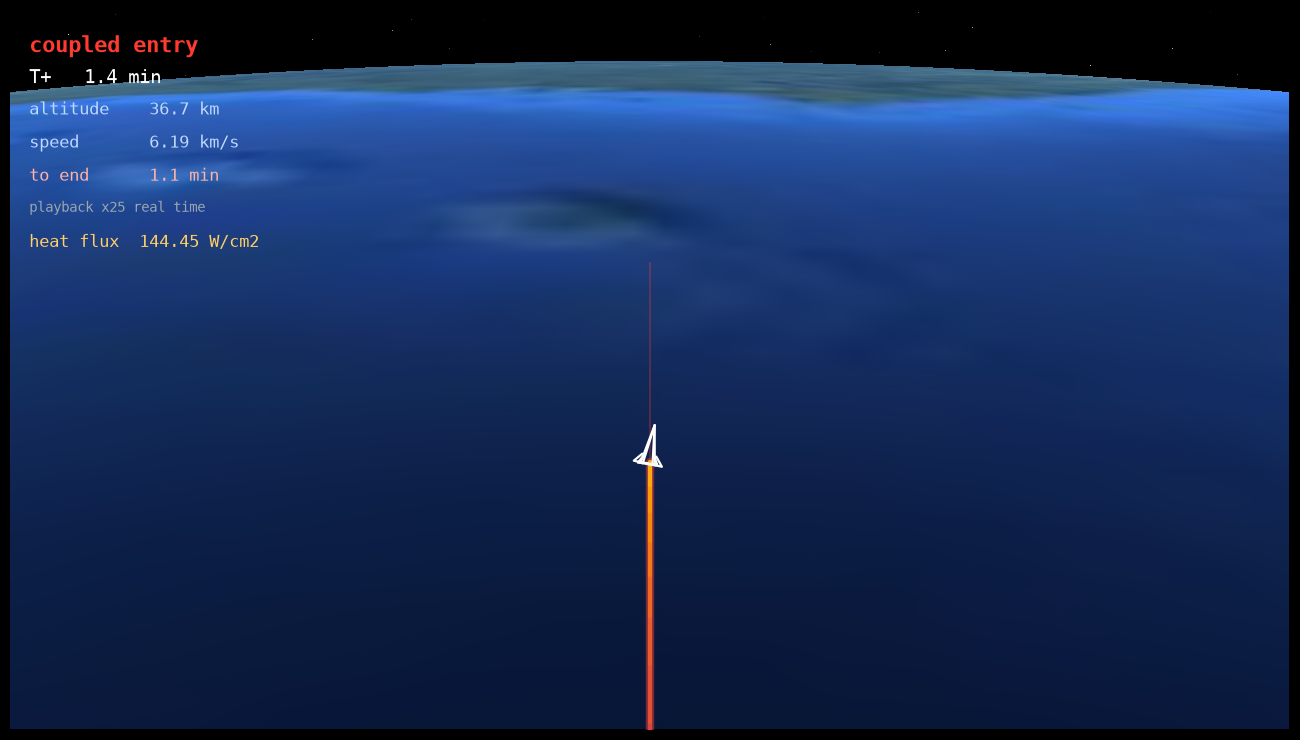

In [ ]:
entry_animator = TrajectoryAnimator(
    entry,
    texture=TEXTURE,
    body_radius=sim.gravity.radius,
    rig=ChaseRig(back_scale=1.4, back_offset=60e3, lift_scale=0.5, lift_offset=25e3,
                 min_altitude=5e3, floor=8e3, fov=np.deg2rad(38.0)),
    style=SceneStyle(track="#FF3B30", heat_cmap="inferno"),
    color_by="stagnation_heat_flux",
    width=1280, height=720, ambient=0.35, backend=BACKEND,
)
path = entry_animator.render_sequence("coupled_entry" + SUFFIX, n_frames=120, fps=20)
print(f"{path}  {path.stat().st_size/1e6:.2f} MB — glyph oriented by the integrated "
      f"attitude, trail coloured by stagnation heat flux")

figure, frame = entry_animator.figure_at(0.55 * impact)
plt.show()


## 9. Terminal approach

The last minutes of the long-way profile at their own pace, using
`SimulationHistory.between` rather than four frames of a 73-minute flight.


terminal plate at T+71.2 min, 16 km


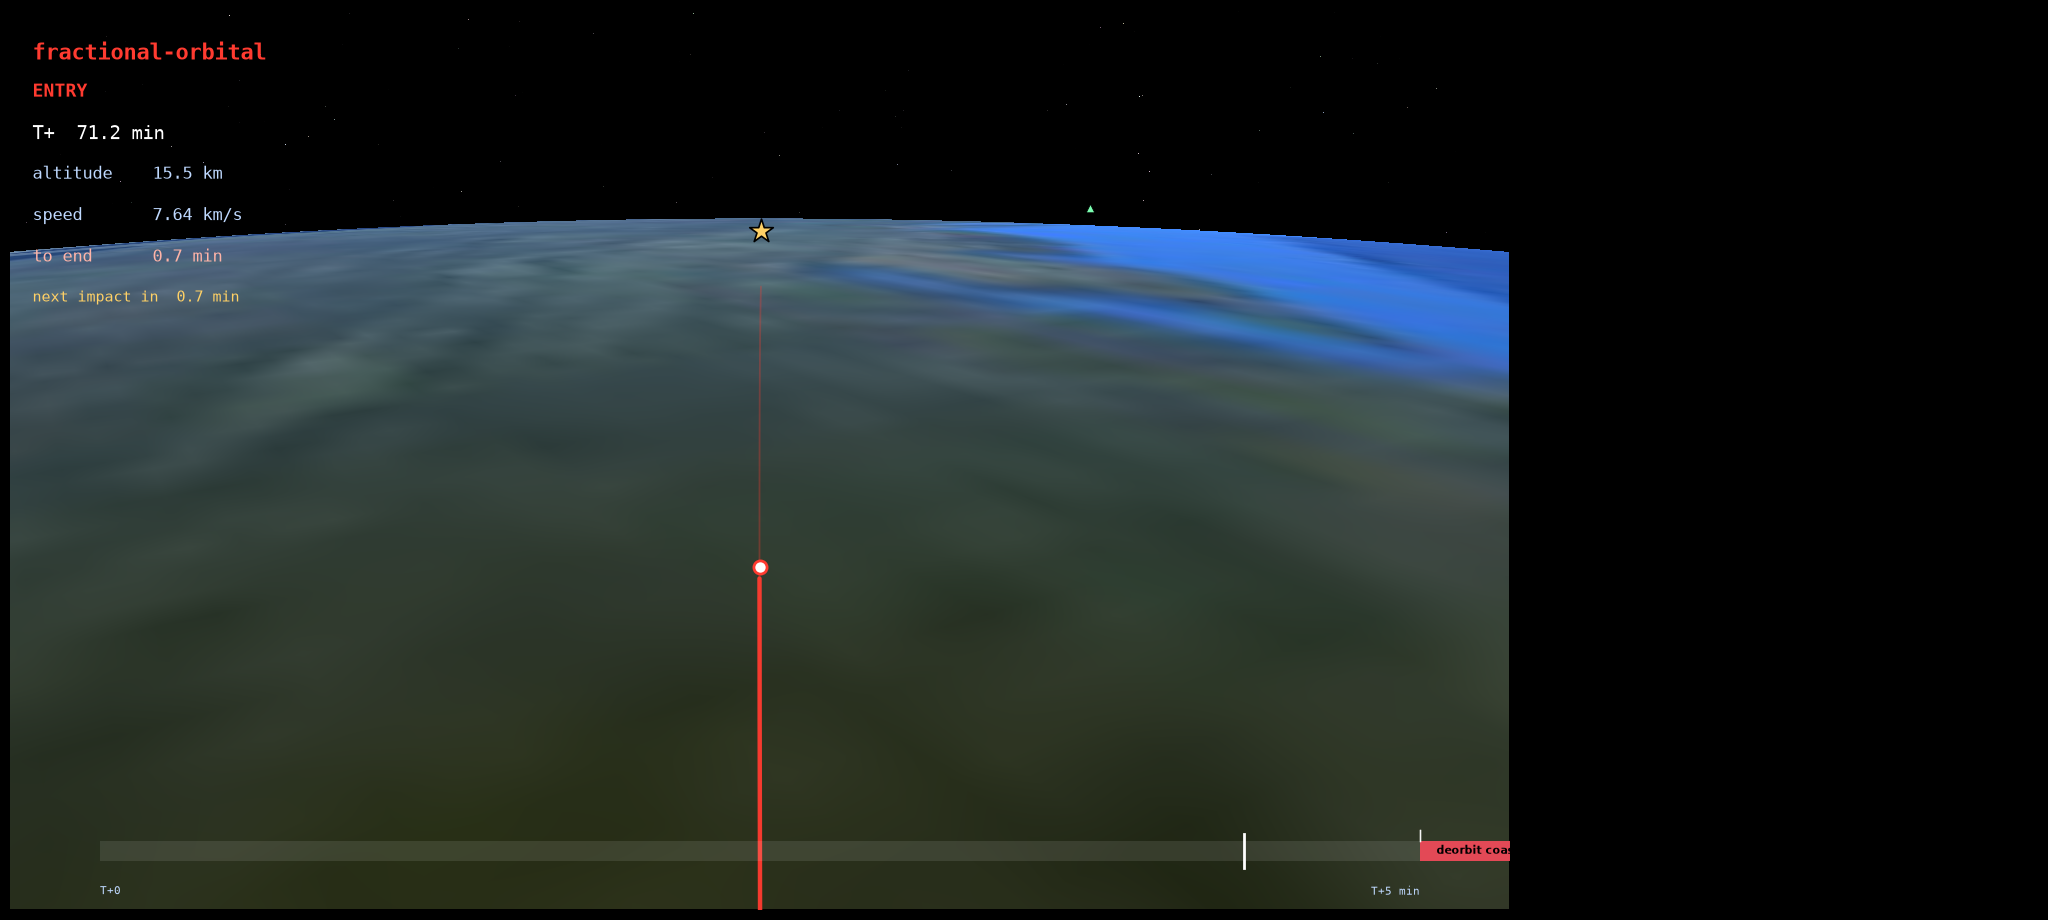

In [ ]:
long_history = HISTORIES["fractional (long way)"]
terminal = long_history.between(long_history.times[-1] - 300.0, long_history.times[-1])
terminal_animator = TrajectoryAnimator(
    terminal,
    texture=TEXTURE, body_radius=R,
    rig=ChaseRig(back_scale=1.2, back_offset=150e3, lift_scale=0.4, lift_offset=60e3,
                 floor=25e3, fov=np.deg2rad(40.0)),
    style=SceneStyle(track="#FF3B30"),
    sites=SITES,
    markers={"aimpoint": (target_xyz, dict(s=320, marker="*", c="#FFD166",
                                           edgecolors="black", linewidths=1.2, zorder=6))},
    width=1500, height=900, backend=BACKEND,
)
figure, frame = terminal_animator.figure_at(terminal.times[-1] - 40.0)
altitude = float(np.linalg.norm(frame.position)) - R
print(f"terminal plate at T+{frame.time/60:.1f} min, {altitude/1e3:.0f} km")
plt.show()


## Limitations

The rendering is a presentation layer and is not calibrated against anything.
At close range it runs out of source: the Blue Marble texture is 4096x2048,
about 11 km per pixel at the equator, so a camera a few hundred kilometres up
magnifies past it and the ground goes soft. That is the texture's limit, not
the renderer's — a higher-resolution image drops straight in. The shading
model — Lambertian terrain, soft terminator, limb glow, ocean glint — exists so
the geometry reads clearly, not to represent radiance.

The analysis limitations are those of `passes.orbital.scenario` and
`passes.orbital.radar`, and they matter more than the pictures:

- **Geometry only.** Detection is "above the horizon mask", with no
  power-aperture, cross-section, waveform, track-initiation or decision-latency
  model. Warning times are upper bounds.
- **Masks are assumed** at 5 degrees, not published, and the assumption binds
  hardest at exactly the low altitudes both fractional profiles use.
- **No boost-phase infrared in this comparison.** The largest omission, and it
  cuts against both fractional profiles: a longer, higher-energy boost is *more*
  visible from space, well before any ground radar sees the vehicle.
  `passes.orbital.radar.boost_phase_sensing` prices it and is not used here.
- **The site list is illustrative** and approximate. "No detection" means no
  site *in this list* — not a claim about the world.
- **The direct fractional profile's ascent is stated, not integrated.** Boost is
  a 300 s, 400 km gravity-turn-shaped ramp to parking altitude. On the long way
  that is 7 % of the flight; on the direct profile it is 21 %, so the
  approximation carries proportionally more weight there.
